In [1]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [2]:
from google.colab import files
uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [5]:
sentiment.shape
trades.shape


(211224, 16)

In [6]:
sentiment.columns
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [7]:
sentiment.isnull().sum()
trades.isnull().sum()


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [8]:
sentiment.duplicated().sum()


np.int64(0)

In [11]:


trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

trades['date'] = trades['Timestamp IST'].dt.date

sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')


sentiment['date'] = sentiment['timestamp'].dt.date


In [12]:
trades[['Timestamp IST','date']].head()


,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [13]:
data = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')

In [16]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum()


In [20]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')

In [21]:
data['Side'].value_counts(normalize=True)

,proportion
Side,
SELL,0.513805
BUY,0.486195


In [24]:
data.groupby('classification')['Size USD'].describe()


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,5349.731843,22306.826180,0.01,282.4825,766.150,2329.9700,1120971.60
Extreme Greed,39992.0,3112.251565,11061.998403,0.00,106.7575,500.050,1882.8375,665771.71
Fear,61837.0,7816.109931,51914.859249,0.00,235.6300,735.960,2499.9700,3921430.72
Greed,50303.0,5736.884375,30533.418602,0.00,184.1300,555.000,2100.7000,2227114.71
Neutral,37686.0,4782.732661,37461.883466,0.01,175.5400,547.655,1994.2050,3641180.84


<Axes: xlabel='classification', ylabel='Closed PnL'>

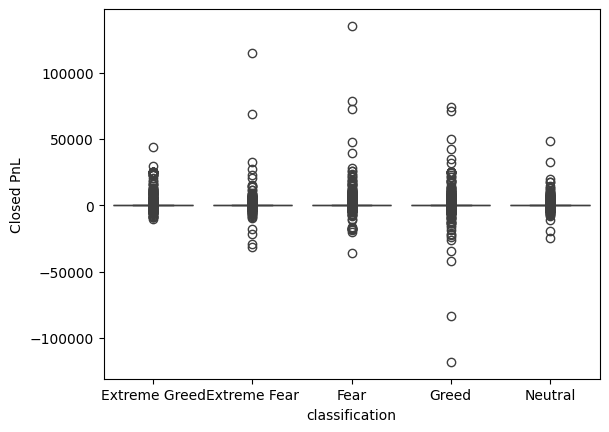

In [25]:
sns.boxplot(x='classification', y='Closed PnL', data=data)

<Axes: xlabel='classification', ylabel='count'>

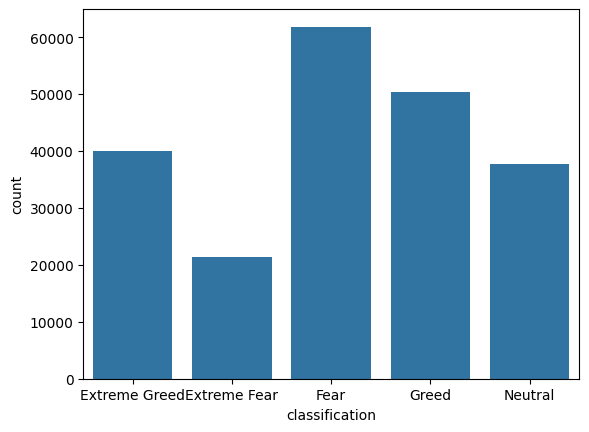

In [26]:
sns.countplot(x='classification', data=data)

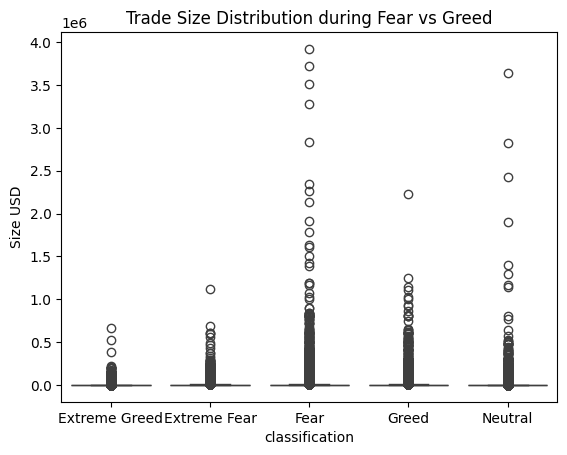

In [27]:
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Trade Size Distribution during Fear vs Greed")
plt.show()

In [28]:
avg_size_per_trader = data.groupby('Account')['Size USD'].mean().reset_index()

In [29]:
data['risk_segment'] = np.where(data['Size USD'] > data['Size USD'].median(), 'High Risk', 'Low Risk')

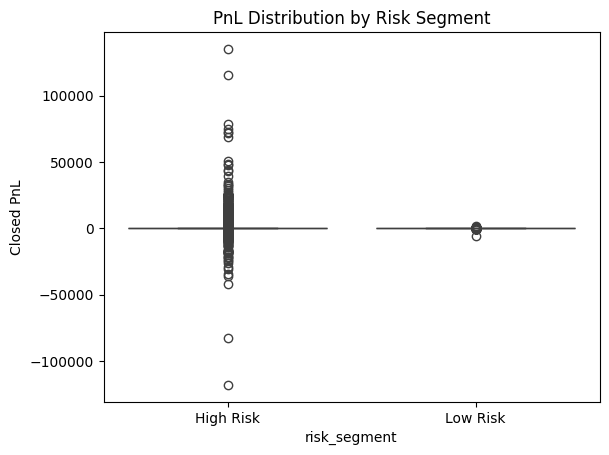

In [30]:
sns.boxplot(x='risk_segment', y='Closed PnL', data=data)
plt.title("PnL Distribution by Risk Segment")
plt.show()

In [34]:
trade_counts = data.groupby('Account').size()

frequent_traders = trade_counts[trade_counts > 50].index

data['trader_type'] = np.where(data['Account'].isin(frequent_traders), 'Frequent', 'Infrequent')

In [35]:
pnl_by_trader = data.groupby('Account')['Closed PnL'].sum()

winners = pnl_by_trader[pnl_by_trader > 0].index

data['performance'] = np.where(data['Account'].isin(winners), 'Winner', 'Loser')

In [36]:
plt.savefig("pnl_vs_sentiment.png")

<Figure size 640x480 with 0 Axes>

In [37]:
data['profit_bucket'] = (data['Closed PnL'] > 0).astype(int)

In [40]:
data['sentiment_num'] = data['classification'].map({'Fear':0,'Greed':1})

In [47]:
X.isnull().sum()

,0
sentiment_num,99084
Size USD,0


In [48]:
data_model = data[['sentiment_num','Size USD','profit_bucket']].dropna()

In [49]:
X = data_model[['sentiment_num','Size USD']]
y = data_model['profit_bucket']

In [50]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [52]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
accuracy_score(y_test,pred)


0.5997859818084538

In [54]:
trader_features = data.groupby('Account').agg({
'Size USD':'mean',
'Closed PnL':'sum',
'Side':'count'
}).reset_index()

In [55]:
trader_features.columns = ['Account','avg_size','total_pnl','num_trades']

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,random_state=42)
trader_features['cluster'] = kmeans.fit_predict(trader_features[['avg_size','num_trades']])

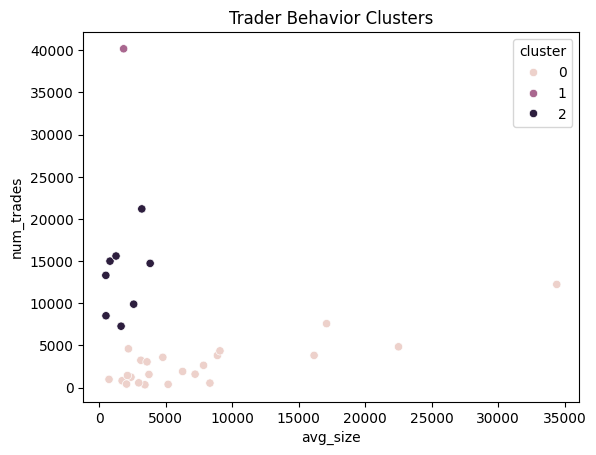

In [57]:
sns.scatterplot(x='avg_size',y='num_trades',hue='cluster',data=trader_features)
plt.title("Trader Behavior Clusters")
plt.show()